In [1]:
import yfinance as yf
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta
from outils import *
from backtest import *
from metrics import PerformanceMetrics

[*********************100%***********************]  30 of 30 completed
[*********************100%***********************]  1 of 1 completed


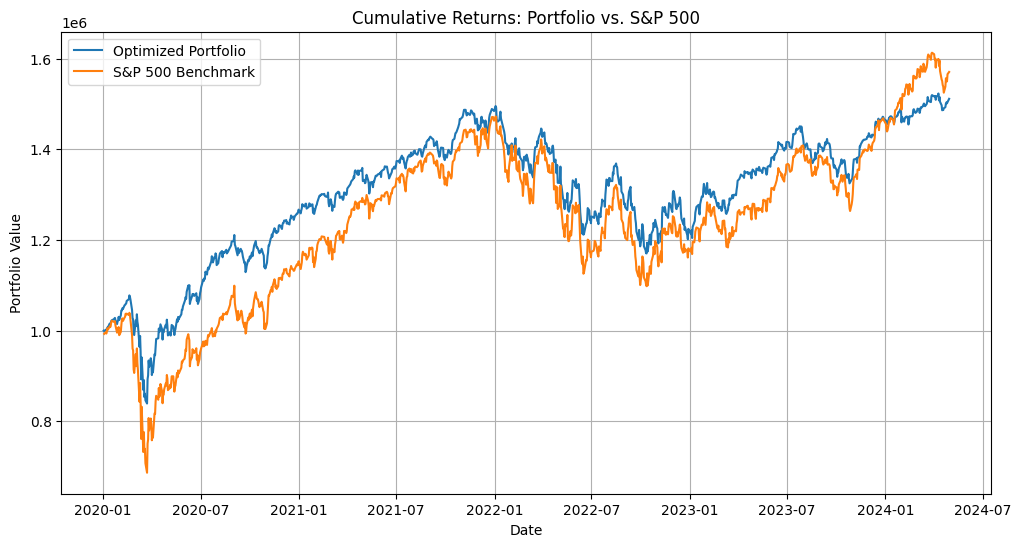

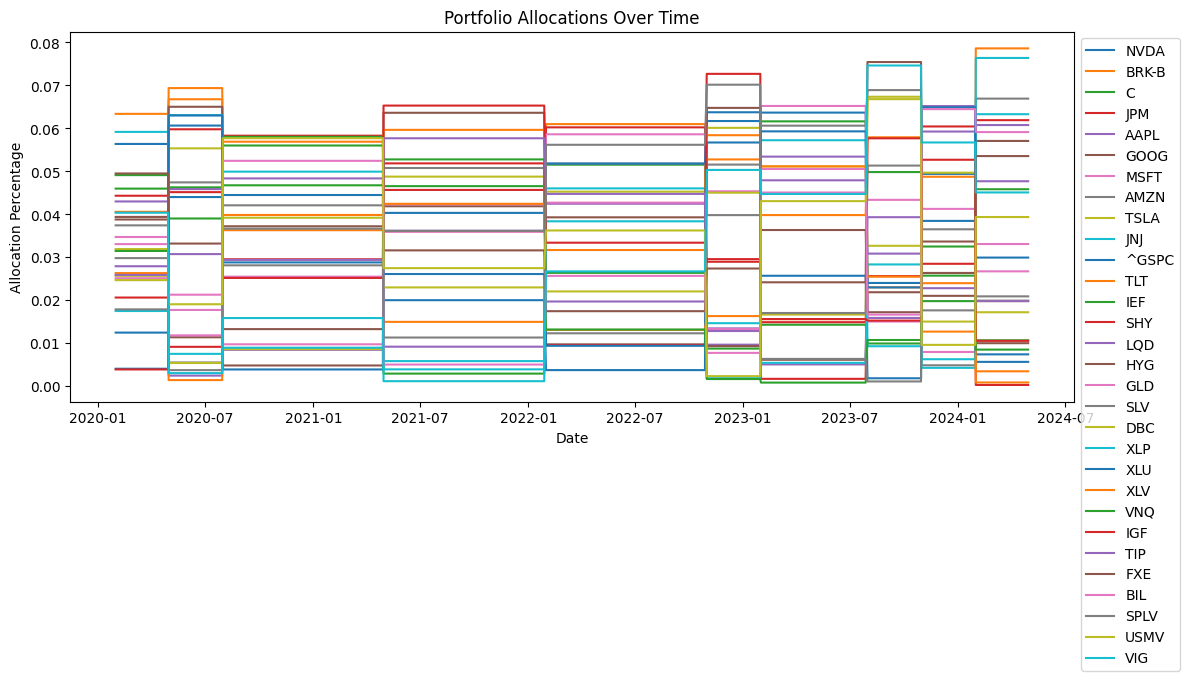

In [2]:
# Define parameters
tickers = [
    # Ações Individuais
    'NVDA', 'BRK-B', 'C', 'JPM', 'AAPL', 'GOOG', 'MSFT', 'AMZN', 'TSLA', 'JNJ',
    
    # Índices
    '^GSPC',
    
    # ETFs de Renda Fixa
    'TLT',  # Long-term Treasury ETF
    'IEF',  # 7-10 Year Treasury Bond ETF
    'SHY',  # 1-3 Year Treasury Bond ETF
    'LQD',  # Investment Grade Corporate Bond ETF
    'HYG',  # High Yield Corporate Bond ETF
    
    # ETFs de Commodities
    'GLD',  # Gold ETF
    'SLV',  # Silver ETF
    'DBC',  # Commodity Index ETF
    
    # ETFs de Setores Defensivos
    'XLP',  # Consumer Staples Sector ETF
    'XLU',  # Utilities Sector ETF
    'XLV',  # Health Care Sector ETF
    
    # ETFs de Imóveis
    'VNQ',  # Real Estate ETF
    
    # ETFs de Infraestrutura
    'IGF',  # Global Infrastructure ETF
    
    # ETFs Protegidos contra a Inflação
    'TIP',  # TIPS Bond ETF
    
    # ETFs de Moedas Estrangeiras
    'FXE',  # Euro Currency ETF
    
    # ETFs de Caixa ou Equivalentes
    'BIL',  # 1-3 Month T-Bill ETF
    
    # ETFs de Baixa Volatilidade e Estratégias Defensivas
    'SPLV',  # Low Volatility ETF
    'USMV',  # Minimum Volatility ETF
    'VIG',   # Dividend Appreciation ETF
]

start_date = '2020-01-01'
end_date = '2024-04-30'
initial_investment = 1_000_000

# Download historical adjusted closing prices
data = yf.download(tickers, start=start_date, end=end_date)['Adj Close']

# Remove timezone info
data.index = data.index.tz_localize(None)

# Download benchmark data
benchmark_ticker = '^GSPC'
benchmark_data = yf.download(benchmark_ticker, start=start_date, end=end_date)['Adj Close']
benchmark_data.index = benchmark_data.index.tz_localize(None)

# Defining parameters
parameters = {
    'w_return': 0.0,
    'w_momentum': 0.0,
    'w_mean_reversion': 0.0,
    'w_deviation': 0.0,
    'w_sortino': 0,
    'w_cvar': -0.0,
    'w_drawdown': -2.0,
    'w_transaction_cost': -0.5,
    'w_concentration': -0.5,
    'w_portfolio_volatility': -0.5,
    'alpha': 0.95,
    'target_return': 0,
    'risk_free_rate': 0.02
}

# Run backtest with PSO optimization
portfolio_values, allocations_df = backtest_pso(
    data=data,
    tickers=tickers,
    start_date=start_date,
    end_date=end_date,
    fitness_function='custom',
    rebalance_period='3ME',
    initial_investment=initial_investment,
    **parameters  # Expande o dicionário como **kwargs
)

# Ensure allocations_df index is datetime and sorted
allocations_df.index = pd.to_datetime(allocations_df.index)
allocations_df = allocations_df.sort_index()

# Extend allocations to daily frequency by forward-filling
allocations_daily = allocations_df.reindex(data.index, method='ffill')

# Remove any NaN values
portfolio_values = portfolio_values.dropna()

# Calculate benchmark cumulative returns
benchmark_returns = benchmark_data.pct_change().dropna()
benchmark_cumulative_returns = (1 + benchmark_returns).cumprod() * initial_investment

# Align benchmark data with portfolio dates
benchmark_cumulative_returns = benchmark_cumulative_returns[benchmark_cumulative_returns.index.isin(portfolio_values.index)]

plot_returns(portfolio_values=portfolio_values, benchmark_cumulative_returns=benchmark_cumulative_returns)
plot_portfolio_composition(allocations_daily=allocations_daily)

In [3]:
# Calculate daily returns
portfolio_daily_returns = portfolio_values.pct_change().dropna()
benchmark_daily_returns = benchmark_returns[benchmark_returns.index.isin(portfolio_daily_returns.index)]

metrics = PerformanceMetrics()

# Calculate risk metrics for the portfolio
portfolio_annual_return = metrics.calculate_annualized_return(portfolio_daily_returns)
portfolio_annual_volatility = metrics.calculate_annualized_volatility(portfolio_daily_returns)
portfolio_sharpe_ratio = metrics.calculate_sharpe_ratio(portfolio_daily_returns)
portfolio_max_drawdown = metrics.calculate_max_drawdown(portfolio_values)

# Calculate risk metrics for the benchmark
benchmark_annual_return = metrics.calculate_annualized_return(benchmark_daily_returns)
benchmark_annual_volatility = metrics.calculate_annualized_volatility(benchmark_daily_returns)
benchmark_sharpe_ratio = metrics.calculate_sharpe_ratio(benchmark_daily_returns)
benchmark_max_drawdown = metrics.calculate_max_drawdown(benchmark_cumulative_returns)

# Print risk metrics
print("Risk Metrics:")
print("\nOptimized Portfolio:")
print(f"Annualized Return: {portfolio_annual_return:.2%}")
print(f"Annualized Volatility: {portfolio_annual_volatility:.2%}")
print(f"Sharpe Ratio: {portfolio_sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {portfolio_max_drawdown:.2%}")

print("\nS&P 500 Benchmark:")
print(f"Annualized Return: {benchmark_annual_return:.2%}")
print(f"Annualized Volatility: {benchmark_annual_volatility:.2%}")
print(f"Sharpe Ratio: {benchmark_sharpe_ratio:.2f}")
print(f"Maximum Drawdown: {benchmark_max_drawdown:.2%}")

Risk Metrics:

Optimized Portfolio:
Annualized Return: 10.05%
Annualized Volatility: 15.47%
Sharpe Ratio: 0.57
Maximum Drawdown: -22.13%

S&P 500 Benchmark:
Annualized Return: 11.03%
Annualized Volatility: 22.35%
Sharpe Ratio: 0.49
Maximum Drawdown: -33.92%
